# Precipitation Equilibrium — Calcite

This notebook demonstrates the active-set Newton-Raphson precipitation loop
in `NRChemicalEquilibriumEngine`.  When the ionic activity product (IAP) for a mineral
exceeds the solubility product (Ksp), the solver enforces equilibrium by
finding the amount precipitated (ξ mol/L) such that IAP = Ksp.

The mineral is declared as an `EquilibriumReaction` with one
`StoichiometryEntry(phase="solid")` (the mineral, activity = 1) and one or
more `StoichiometryEntry(phase="liquid")` (the dissolved ionic products).
Ca²⁺ is passed as a strong ion; the outer loop adjusts its effective
concentration to account for precipitation.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def _find_repo():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise RuntimeError("Run from inside the PyOMES repo")

sys.path.insert(0, str(_find_repo() / "models"))

from PyOMES.chemistry.common_species import (
    H2O, H_plus, OH_minus,
    CO2, HCO3_minus, CO3_2minus,
    Ca_plus_plus,
)
from PyOMES.chemistry.species import Species
from PyOMES.reactions.equilibrium import EquilibriumReaction
from PyOMES.reactions.stoichiometry import StoichiometryEntry
from PyOMES.chemical_equilibrium.nr_engine import NRChemicalEquilibriumEngine
from PyOMES.chemical_equilibrium.activity_models import DaviesActivityModel

def _e(sp, phase, coeff):
    return StoichiometryEntry(species=sp, phase=phase, coefficient=coeff)

davies = DaviesActivityModel()

# Shared carbonate reactions
water = EquilibriumReaction(
    stoichiometry=[_e(H2O,"liquid",-1), _e(H_plus,"liquid",+1), _e(OH_minus,"liquid",+1)],
    log_K=-14.0, label="water",
)
co2_first = EquilibriumReaction(
    stoichiometry=[_e(CO2,"liquid",-1), _e(H2O,"liquid",-1),
                   _e(HCO3_minus,"liquid",+1), _e(H_plus,"liquid",+1)],
    log_K=-6.35, total_id="CO2", label="co2_first",
)
co2_second = EquilibriumReaction(
    stoichiometry=[_e(HCO3_minus,"liquid",-1),
                   _e(CO3_2minus,"liquid",+1), _e(H_plus,"liquid",+1)],
    log_K=-10.33, total_id="CO2", label="co2_second",
)
carb_rxns = [water, co2_first, co2_second]

# Calcite mineral
CaCO3 = Species(id="CaCO3", atoms={"Ca":1,"C":1,"O":3}, charge=0, MW=100.086)
calcite = EquilibriumReaction(
    stoichiometry=[
        _e(CaCO3,       "solid",  -1),
        _e(Ca_plus_plus,"liquid", +1),
        _e(CO3_2minus,  "liquid", +1),
    ],
    log_K=-8.48,
    label="calcite",
)
Ksp_calcite = 10**(-8.48)

print("Imports OK")


Imports OK


## 1  Background

The saturation index (SI) notebook (03) demonstrated that the NR engine can
flag SI > 0 — calcite precipitation is thermodynamically favoured — but
returned dissolved concentrations as if precipitation were suppressed.

The **precipitation equilibrium** solver extends this: when SI > 0, the outer
active-set loop finds ξ such that

$$\text{IAP}(\xi) = K_{\text{sp}}$$

where

$$\text{IAP} = a_{\text{Ca}^{2+}} \cdot a_{\text{CO}_3^{2-}}, \quad
  a_{\text{Ca}^{2+}} = \gamma_{\text{Ca}} \cdot ([\text{Ca}^{2+}]_\text{total} - \xi)$$

Ca²⁺ is treated as a strong ion with no dissolved complexation (Phase 1
scope).  The dissolved-Ca²⁺ concentration after equilibrium is
$[\text{Ca}^{2+}]_\text{eq} = C_{T,\text{Ca}} - \xi$.

## 2  Declaration

```python
CaCO3 = Species(id="CaCO3", atoms={"Ca":1,"C":1,"O":3}, charge=0, MW=100.086)
calcite = EquilibriumReaction(
    stoichiometry=[
        StoichiometryEntry(species=CaCO3,       phase="solid",  coefficient=-1),
        StoichiometryEntry(species=Ca_plus_plus, phase="liquid", coefficient=+1),
        StoichiometryEntry(species=CO3_2minus,   phase="liquid", coefficient=+1),
    ],
    log_K=-8.48,   # Ksp at 25 °C
    label="calcite",
)
```

Pass to `NRChemicalEquilibriumEngine.from_reactions()` via the `precipitation_reactions`
keyword argument.  The dissolved carbonate reactions go in `equilibrium_reactions`
as before.

In [2]:
engine = NRChemicalEquilibriumEngine.from_reactions(
    carb_rxns,
    precipitation_reactions=[calcite],
    use_activity=True,
    activity_model="davies",
)

# Dissolved-only engine for comparison
engine_dissolved = NRChemicalEquilibriumEngine.from_reactions(
    carb_rxns,
    use_activity=True,
    activity_model="davies",
)

print("Masters:", engine.tableau.masters)
print("Secondaries:", [s.species_id for s in engine.tableau.secondaries])


Masters: ['H+', 'CO2']
Secondaries: ['OH-', 'HCO3-', 'CO3--']


C:\Users\k2473520\AppData\Local\Temp\ipykernel_11952\3773133212.py:1: DeprecationWarning: NRChemicalEquilibriumEngine.from_reactions(precipitation_reactions=...) is deprecated; solid-liquid items are now auto-classified from equilibrium_reactions via StoichiometryEntry(phase='solid') tags (EQUILIBRIUM_CONSTRAINT_UNIFICATION CP2). Pass them directly in equilibrium_reactions instead.
  engine = NRChemicalEquilibriumEngine.from_reactions(


## 3  Single-point solve

**Conditions:** CT_CO₂ = 10 mmol/L, CT_Ca = 2 mmol/L, CT_Na = 5 mmol/L.

These are the same conditions as Section 2 of notebook 03, where SI ≈ +0.42
in the dissolved-only model.  After precipitation equilibrium: IAP = Ksp and
ξ > 0 (some CaCO₃ has precipitated).

In [3]:
T_K    = 298.15
CT_Ca  = 0.002
CT_CO2 = 0.010
CT_Na  = 0.005

# Dissolved-only
out_d = engine_dissolved.solve(
    totals={"CO2": CT_CO2},
    strong_ions={"CT_Ca": CT_Ca, "CT_Na": CT_Na},
    T_K=T_K,
)
I_d = out_d.ionic_strength
g_d = davies.gamma(2, I_d, T_K=T_K)
IAP_d = (g_d * CT_Ca) * (g_d * out_d.species_mol_L["CO3--"])
SI_d  = np.log10(IAP_d / Ksp_calcite)

# Precipitation equilibrium
out_p = engine.solve(
    totals={"CO2": CT_CO2},
    strong_ions={"CT_Ca": CT_Ca, "CT_Na": CT_Na},
    T_K=T_K,
)
xi   = out_p.extra["minerals_xi_mol_L"]["calcite"]
SI_p = out_p.saturation_indices["calcite"]
Ca_eq = CT_Ca - xi

print(f"{'':30s}  {'Dissolved-only':>16}  {'Precipitation eq':>18}")
print("-" * 68)
print(f"{'pH':30s}  {out_d.pH:>16.4f}  {out_p.pH:>18.4f}")
print(f"{'[CO3--] (mol/L)':30s}  {out_d.species_mol_L["CO3--"]:>16.4e}  {out_p.species_mol_L["CO3--"]:>18.4e}")
print(f"{'[Ca2+] effective (mol/L)':30s}  {CT_Ca:>16.4e}  {Ca_eq:>18.4e}")
print(f"{'IAP':30s}  {IAP_d:>16.4e}  {'IAP = Ksp':>18}")
print(f"{'SI':30s}  {SI_d:>16.4f}  {SI_p:>18.4f}")
print(f"{'xi (mol/L precipitated)':30s}  {'—':>16}  {xi:>18.4e}")


                                  Dissolved-only    Precipitation eq
--------------------------------------------------------------------
pH                                        7.2518              7.0108
[CO3--] (mol/L)                       1.0368e-05          5.1117e-06
[Ca2+] effective (mol/L)              2.0000e-03          1.4478e-03
IAP                                   8.7431e-09           IAP = Ksp
SI                                        0.4217             -0.0000
xi (mol/L precipitated)                        —          5.5223e-04


## 4  Dissolved Ca²⁺ depletion curve

As total calcium (CT_Ca) increases above the solubility ceiling set by Ksp
at fixed CT_CO₂, the excess precipitates as CaCO₃.  The dissolved Ca²⁺ rises
until the saturation ceiling is reached, then stays flat while ξ absorbs the
surplus.

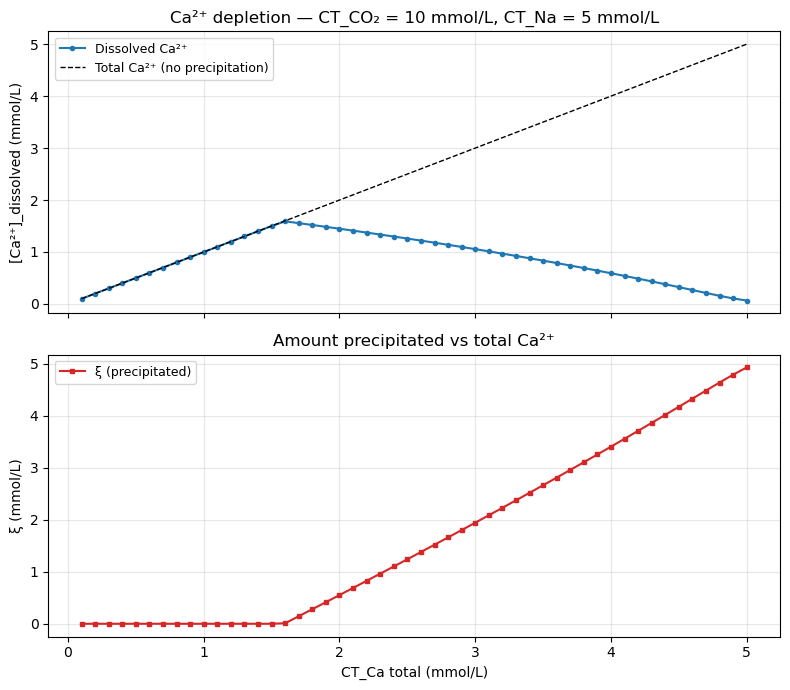

Ksp-set ceiling dissolved Ca²⁺ ≈ 0.780 mmol/L


In [4]:
CT_CO2_fixed = 0.010
CT_Na_fixed  = 0.005

Ca_total_vals = np.linspace(0.0001, 0.005, 50)
Ca_dissolved  = []
xi_vals       = []
SI_vals       = []

for cta in Ca_total_vals:
    o = engine.solve(
        totals={"CO2": CT_CO2_fixed},
        strong_ions={"CT_Ca": cta, "CT_Na": CT_Na_fixed},
        T_K=T_K,
    )
    xi_j = o.extra["minerals_xi_mol_L"]["calcite"]
    xi_vals.append(xi_j)
    Ca_dissolved.append(cta - xi_j)
    SI_vals.append(o.saturation_indices["calcite"])

Ca_dissolved = np.array(Ca_dissolved)
xi_vals      = np.array(xi_vals)
SI_vals      = np.array(SI_vals)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

axes[0].plot(Ca_total_vals*1e3, Ca_dissolved*1e3, "o-", ms=3, color="tab:blue",
             label="Dissolved Ca²⁺")
axes[0].plot(Ca_total_vals*1e3, Ca_total_vals*1e3, "k--", lw=1, label="Total Ca²⁺ (no precipitation)")
axes[0].set_ylabel("[Ca²⁺]_dissolved (mmol/L)")
axes[0].set_title(f"Ca²⁺ depletion — CT_CO₂ = {CT_CO2_fixed*1e3:.0f} mmol/L, CT_Na = {CT_Na_fixed*1e3:.0f} mmol/L")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(Ca_total_vals*1e3, xi_vals*1e3, "s-", ms=3, color="tab:red",
             label="ξ (precipitated)")
axes[1].set_xlabel("CT_Ca total (mmol/L)")
axes[1].set_ylabel("ξ (mmol/L)")
axes[1].set_title("Amount precipitated vs total Ca²⁺")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Ksp-set ceiling dissolved Ca²⁺ ≈ {Ca_dissolved[Ca_total_vals >= 0.002].mean()*1e3:.3f} mmol/L")


## 5  Dissolution from a CaCO₃ solid feed

Starting with a known CaCO₃ solid (n_mol_solid mol/L), no dissolved Ca²⁺
initially: CaCO₃ dissolves until IAP = Ksp.  The model supplies
CT_Ca = n_mol_solid (as if all solid dissolved) and the outer loop
re-precipitates the excess.

At equilibrium:
- dissolved Ca²⁺ = CT_Ca − ξ
- remaining solid ≈ ξ (re-precipitated amount)

The fraction dissolved depends on the carbonate alkalinity (CT_CO₂, CT_Na)
which controls the pH and therefore [CO₃²⁻] and the Ksp ceiling.

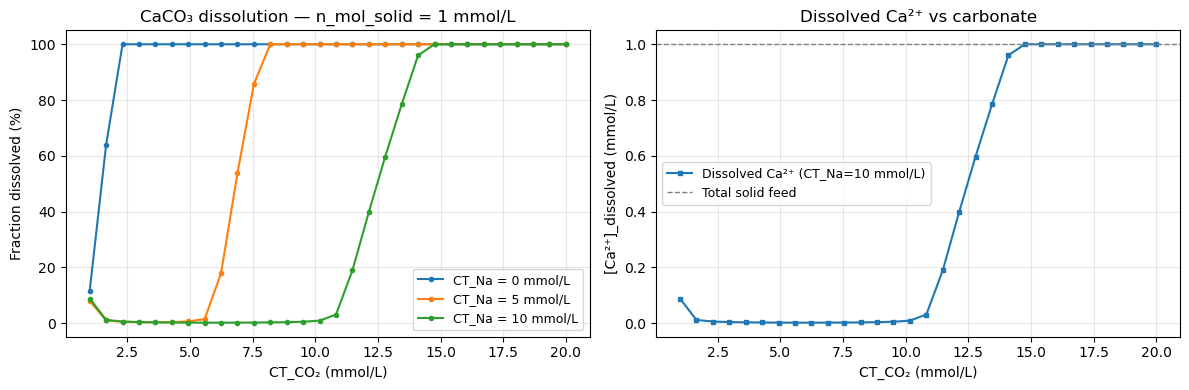

In [5]:
n_mol_solid = 0.001   # mol/L CaCO3(s) available
CT_CO2_vals = np.linspace(0.001, 0.020, 30)
CT_Na_vals  = [0.000, 0.005, 0.010]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for CT_Na in CT_Na_vals:
    frac_dissolved = []
    for CT_CO2 in CT_CO2_vals:
        o = engine.solve(
            totals={"CO2": CT_CO2},
            strong_ions={"CT_Ca": n_mol_solid, "CT_Na": CT_Na},
            T_K=T_K,
        )
        xi_j = o.extra["minerals_xi_mol_L"]["calcite"]
        # Fraction dissolved = (n_mol_solid - xi) / n_mol_solid
        frac = (n_mol_solid - xi_j) / n_mol_solid
        frac_dissolved.append(frac)

    lbl = f"CT_Na = {CT_Na*1e3:.0f} mmol/L"
    axes[0].plot(CT_CO2_vals*1e3, np.array(frac_dissolved)*100, "o-", ms=3, label=lbl)

axes[0].set_xlabel("CT_CO₂ (mmol/L)")
axes[0].set_ylabel("Fraction dissolved (%)")
axes[0].set_title(f"CaCO₃ dissolution — n_mol_solid = {n_mol_solid*1e3:.0f} mmol/L")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Single trace: dissolved Ca vs CT_CO2
Ca_diss_vals = []
for CT_CO2 in CT_CO2_vals:
    o = engine.solve(
        totals={"CO2": CT_CO2},
        strong_ions={"CT_Ca": n_mol_solid, "CT_Na": 0.010},
        T_K=T_K,
    )
    Ca_diss_vals.append(n_mol_solid - o.extra["minerals_xi_mol_L"]["calcite"])

axes[1].plot(CT_CO2_vals*1e3, np.array(Ca_diss_vals)*1e3, "s-", ms=3,
             color="tab:blue", label="Dissolved Ca²⁺ (CT_Na=10 mmol/L)")
axes[1].axhline(n_mol_solid*1e3, color="gray", ls="--", lw=1, label="Total solid feed")
axes[1].set_xlabel("CT_CO₂ (mmol/L)")
axes[1].set_ylabel("[Ca²⁺]_dissolved (mmol/L)")
axes[1].set_title("Dissolved Ca²⁺ vs carbonate")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6  Scope and next steps

**Phase 1 scope (this notebook):**

- `NRChemicalEquilibriumEngine` with `precipitation_reactions=` finds ξ and returns
  `out.extra["minerals_xi_mol_L"]["calcite"]` and `out.saturation_indices["calcite"]`.
- Ca²⁺ is a strong ion with **no dissolved complexation** (no CaHCO₃⁺, CaCO₃⁰,
  etc.) — this is the dominant species in most natural waters, so the error is
  small at low ionic strength.
- SI ≈ 0 at equilibrium (verified by tests and Section 3 above).

**Phase 2 (NR_PRECIPITATION_CV_INTEGRATION.md):**

- ξ writeback to `SolidPhase.n_mol` on a `ControlVolume`.
- `ControlVolume._read_from_phases` sums liquid + solid contributions.
- Lazy-creation / consistency enforcement of `SolidPhase` objects.
- Multiple co-precipitating minerals sharing a common component (e.g.
  calcite + aragonite both consuming CT_CO₂).

**Not in scope:**

- Kinetic crystallisation rates — a separate future phase.
- Redox equilibria (pe as a master) — deferred per NR design doc.